# Importing Libraries & Defining paths

In [ ]:
# Defining project paths
BASE_DIR = "D:/Capstone/capstone_repo"
DATA_DIR = f"{BASE_DIR}/data/raw"
COLLECTION_OUTPUT_DIR = f"{BASE_DIR}/data/collection_output"
import os
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(COLLECTION_OUTPUT_DIR, exist_ok=True)

In [ ]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd

import matplotlib.pyplot as plt

# Casablanca Street Network

In [22]:
# Define the place to download the street network
place_name = "Casablanca, Morocco"

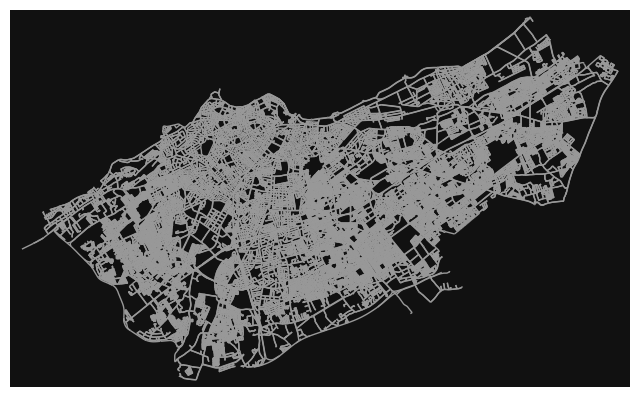

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [23]:
# Download the street network
print(f"Downloading street network for {place_name}...")
G = ox.graph_from_place(place_name, network_type='drive')
ox.plot_graph(G, node_size=0)

## Basic Street network Stats

In [5]:
# what sized area does network cover in square meters?
G_proj = ox.projection.project_graph(G)
nodes_proj = ox.convert.graph_to_gdfs(G_proj, edges=False)
graph_area_m = nodes_proj.union_all().convex_hull.area
graph_area_m

254214807.77543947

In [6]:
# show some basic stats about the network
ox.stats.basic_stats(G_proj, area=graph_area_m, clean_int_tol=15)

{'n': 37578,
 'm': 99373,
 'k_avg': 5.28889243706424,
 'edge_length_total': 6522495.255765503,
 'edge_length_avg': 65.63649337109177,
 'streets_per_node_avg': 3.0546330299643407,
 'streets_per_node_counts': {0: 0,
  1: 2295,
  2: 65,
  3: 28596,
  4: 6542,
  5: 74,
  6: 6},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.061072968226089736,
  2: 0.001729735483527596,
  3: 0.7609771674916175,
  4: 0.17409122358826973,
  5: 0.00196923731970834,
  6: 0.0001596678907871627},
 'intersection_count': 35283,
 'street_length_total': 3926762.5271326625,
 'street_segment_count': 57312,
 'street_length_avg': 68.5155382316559,
 'circuity_avg': 1.0383611618939148,
 'self_loop_proportion': 0.0010817978782802903,
 'clean_intersection_count': 19159,
 'node_density_km': 147.81987063945743,
 'intersection_density_km': 138.79207237670914,
 'edge_density_km': 25657.416705352374,
 'street_density_km': 15446.63177371385,
 'clean_intersection_density_km': 75.3653973490171}

## Street Centrality

In [ ]:
# convert graph to line graph so edges become nodes and vice versa
edge_centrality = nx.closeness_centrality(nx.line_graph(G))
nx.set_edge_attributes(G, edge_centrality, "edge_centrality") # 456m44.2s

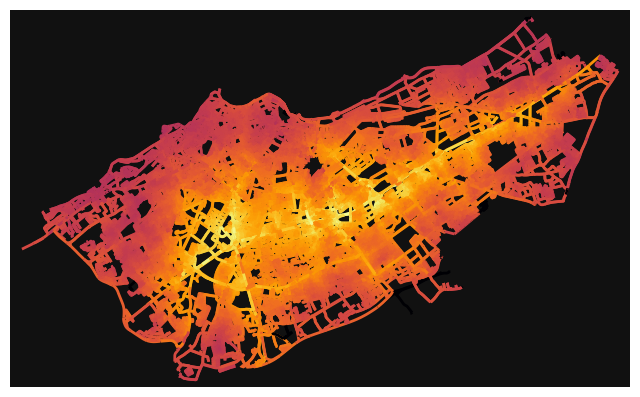

In [9]:
# color edges in original graph with closeness centralities from line graph
ec = ox.plot.get_edge_colors_by_attr(G, "edge_centrality", cmap="inferno")
fig, ax = ox.plot.plot_graph(G, edge_color=ec, edge_linewidth=2, node_size=0)

## Convert graph to GeoDataframe; Export nodes & edges to shapefiles

In [24]:
# Convert graph to GeoDataFrames
nodes, edges = ox.graph_to_gdfs(G)

In [26]:
# Export shapefiles
print(f"Saving data to {DATA_DIR}...")
if not os.path.exists(os.path.join(DATA_DIR, "NetworkGraph")):
    os.makedirs(os.path.join(DATA_DIR, "NetworkGraph"))
nodes.to_file(os.path.join(f"{DATA_DIR}/NetworkGraph", "nodes.shp"))
edges.to_file(os.path.join(f"{DATA_DIR}/NetworkGraph", "edges.shp"))

Saving data to D:/Capstone/capstone_repo/data/raw...


C:\Users\afafb\AppData\Local\Temp\ipykernel_8964\1409774928.py:5: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  nodes.to_file(os.path.join(f"{DATA_DIR}/NetworkGraph", "nodes.shp"))
c:\Users\afafb\AppData\Local\Programs\Python\Python310\lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(


# Districts Data

In [3]:
# Load administrative boundaries for Casablanca: data downloaded from GADM
districts = gpd.read_file(f"{DATA_DIR}/gadm/gadm41_MAR_4.shp") 
districts.head()

,GID_4,GID_0,COUNTRY,GID_1,NAME_1,GID_2,NAME_2,GID_3,NAME_3,NAME_4,VARNAME_4,TYPE_4,ENGTYPE_4,CC_4,geometry
0,MAR.1.1.1.1_1,MAR,Morocco,MAR.1_1,Chaouia - Ouardigha,MAR.1.1_1,Ben Slimane,MAR.1.1.1_1,Ben Slimane,Ahlaf,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-7.21601 33.33524, -7.20212 33.34536..."
1,MAR.1.1.1.2_1,MAR,Morocco,MAR.1_1,Chaouia - Ouardigha,MAR.1.1_1,Ben Slimane,MAR.1.1.1_1,Ben Slimane,Ain Tizgha,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-7.01937 33.57966, -7.02208 33.57954..."
2,MAR.1.1.1.3_1,MAR,Morocco,MAR.1_1,Chaouia - Ouardigha,MAR.1.1_1,Ben Slimane,MAR.1.1.1_1,Ben Slimane,Fdalate,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-7.25532 33.68698, -7.24397 33.66458..."
3,MAR.1.1.1.4_1,MAR,Morocco,MAR.1_1,Chaouia - Ouardigha,MAR.1.1_1,Ben Slimane,MAR.1.1.1_1,Ben Slimane,Mellila,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-6.96569 33.36103, -6.96891 33.35316..."
4,MAR.1.1.1.5_1,MAR,Morocco,MAR.1_1,Chaouia - Ouardigha,MAR.1.1_1,Ben Slimane,MAR.1.1.1_1,Ben Slimane,Moualine El Ghaba,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-7.12737 33.72615, -7.1226 33.71605,..."


In [4]:
# Filter to only include districts that contain "Casablanca"
casablanca_districts = districts[districts['NAME_2'].str.contains("Casablanca", case=False, na=False)]

In [5]:
casablanca_districts = casablanca_districts.to_crs(epsg=4326)

In [6]:
casablanca_districts.head()

,GID_4,GID_0,COUNTRY,GID_1,NAME_1,GID_2,NAME_2,GID_3,NAME_3,NAME_4,VARNAME_4,TYPE_4,ENGTYPE_4,CC_4,geometry
346,MAR.5.1.1.1_1,MAR,Morocco,MAR.5_1,Grand Casablanca,MAR.5.1_1,Casablanca,MAR.5.1.1_1,Bouskoura,Bouskoura,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-7.68792 33.41272, -7.68806 33.41307..."
347,MAR.5.1.1.2_1,MAR,Morocco,MAR.5_1,Grand Casablanca,MAR.5.1_1,Casablanca,MAR.5.1.1_1,Bouskoura,Dar Bouazza,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-7.76684 33.45884, -7.77442 33.45698..."
348,MAR.5.1.2.1_1,MAR,Morocco,MAR.5_1,Grand Casablanca,MAR.5.1_1,Casablanca,MAR.5.1.2_1,Mediouna,El Majjatia Oulad Taleb,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-7.52672 33.40465, -7.52772 33.40506..."
349,MAR.5.1.2.2_1,MAR,Morocco,MAR.5_1,Grand Casablanca,MAR.5.1_1,Casablanca,MAR.5.1.2_1,Mediouna,Lahraouyine,NA,Commune Rural,Rural Commune,NA,"POLYGON ((-7.4977 33.50524, -7.50182 33.5069, ..."
350,MAR.5.1.3.1_1,MAR,Morocco,MAR.5_1,Grand Casablanca,MAR.5.1_1,Casablanca,MAR.5.1.3_1,NA (Ahl Laghlam),Ahl Laghlam,NA,Commune Urbaine,Urban Commune,NA,"POLYGON ((-7.49482 33.55348, -7.50156 33.55503..."


In [7]:
# Check unique district names to understand the structure of the data
casablanca_districts["NAME_3"].unique()

array(['Bouskoura', 'Mediouna', 'NA (Ahl Laghlam)', 'NA (Ain Chock)',
       'NA (Ain Harrouda)', 'NA (Ain Sebaa)', 'NA (Al Fida)',
       'NA (Al Idrissia)', 'NA (Anfa)', 'NA (Assoukhour Assawda)',
       'NA (Ben Msick)', 'NA (Bou Chentouf)', 'NA (El Maarif)',
       'NA (Hay Hassani)', 'NA (Hay Mohammadi)', 'NA (Lissasfa)',
       'NA (Machouar Casablanca)', 'NA (Mediouna)', 'NA (Mers Sultan)',
       'NA (Moulay Rachid)', 'NA (Moulay Youssef)', 'NA (Nouaceur)',
       'NA (Salmia)', 'NA (Sbata)', 'NA (Sidi Belyout)',
       'NA (Sidi Bernoussi)', 'NA (Sidi Maarouf)', 'NA (Sidi Moumen)',
       'NA (Sidi Othmane)', 'NA (Tit Mellil)', 'Tit Mellil'], dtype=object)

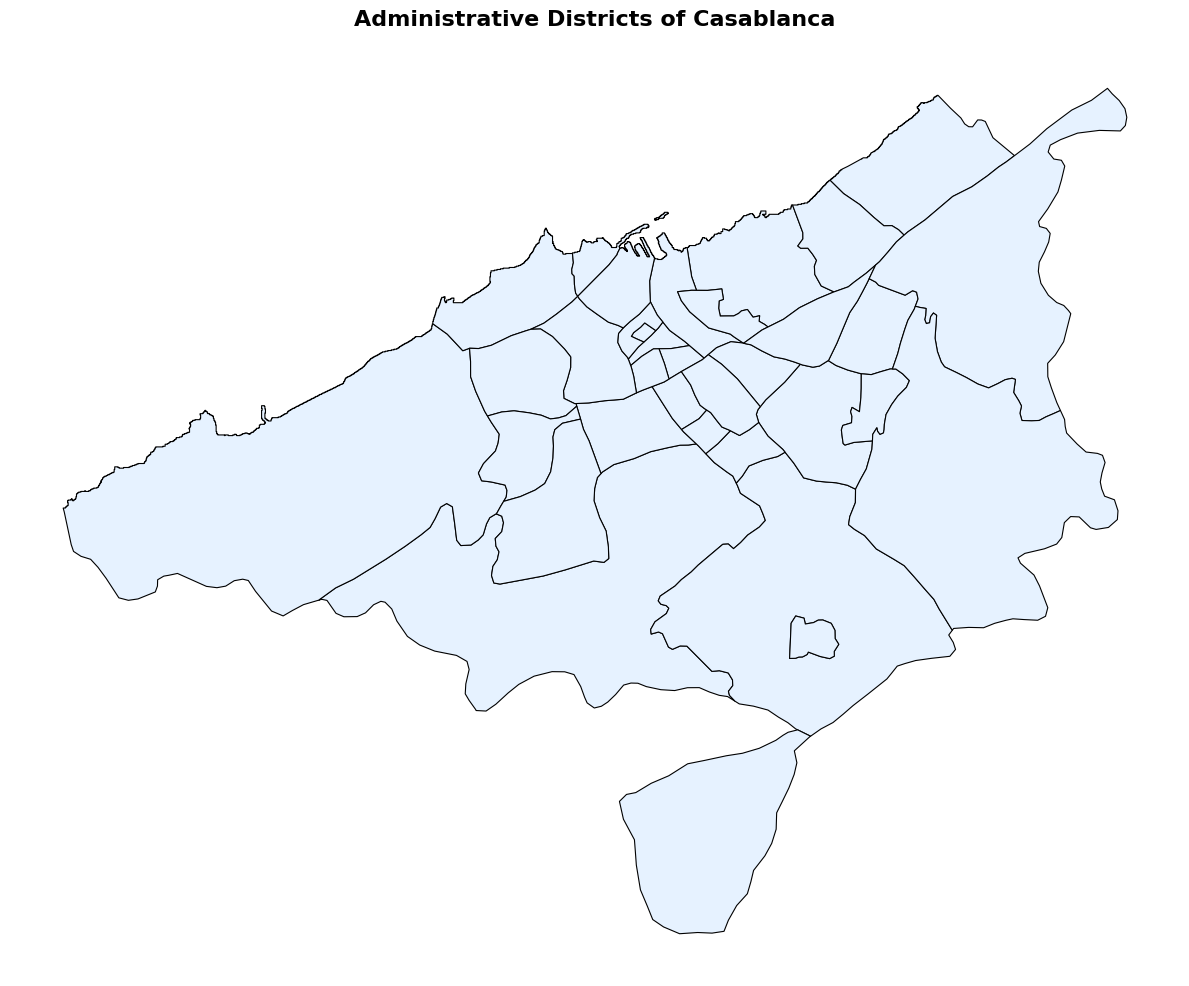

In [31]:
# Plotting the districts
fig, ax = plt.subplots(figsize=(12, 12))

# Plot districts
casablanca_districts.plot(
    ax=ax,
    edgecolor='black',
    facecolor='#e6f2ff',  # softer blue
    linewidth=0.8
)

# Title
ax.set_title(
    "Administrative Districts of Casablanca",
    fontsize=16,
    fontweight='bold',
    pad=15
)

# Remove axes for clean map
ax.set_axis_off()

# Tight layout
plt.tight_layout()

# Save 
plt.savefig(
    f'{COLLECTION_OUTPUT_DIR}/CasablancaDistricts.png',
    dpi=300, 
    bbox_inches='tight'
)

plt.show()

In [9]:
# Save the filtered districts to a new CSV file
casablanca_districts.to_csv(f"{DATA_DIR}/casablanca_districts.csv", index=False)

# Healthcare facilities (hospitals, clinics)

In [10]:
# Load the processed district boundaries for Casablanca, to get healthcare facilities within these boundaries
districts = gpd.read_file(f"{BASE_DIR}/data/processed/Casablanca_Districts.gpkg")

# Defining tags to filter data for healthcare facilities (hospitals and clinics)
tags = {"amenity": ["hospital", "clinic"]}

# Fetch healthcare facilities within the district boundaries
healthcare= ox.features_from_polygon(districts.unary_union, tags)

healthcare = healthcare[['name', 'amenity', 'geometry']]
healthcare.head()

C:\Users\afafb\AppData\Local\Temp\ipykernel_8964\1918864887.py:8: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  healthcare= ox.features_from_polygon(districts.unary_union, tags)


name   amenity  \
element id                                                                  
node    2714951127                       Clinique Badr مصحة بدر    clinic   
        2714951128           clinique dentaire casablanca (cdc)    clinic   
        2902579703  Centre consultation et traitement dentaires  hospital   
        3346762457                      Clinique d'accouchement    clinic   
        4057991325                         Hôpital Sidi Othmane  hospital   

                                     geometry  
element id                                     
node    2714951127   POINT (-7.6411 33.59487)  
        2714951128  POINT (-7.64821 33.58741)  
        2902579703   POINT (-7.6206 33.57308)  
        3346762457  POINT (-7.62409 33.59306)  
        4057991325   POINT (-7.5733 33.55854)

C:\Users\afafb\AppData\Local\Temp\ipykernel_8964\949026510.py:33: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper right')


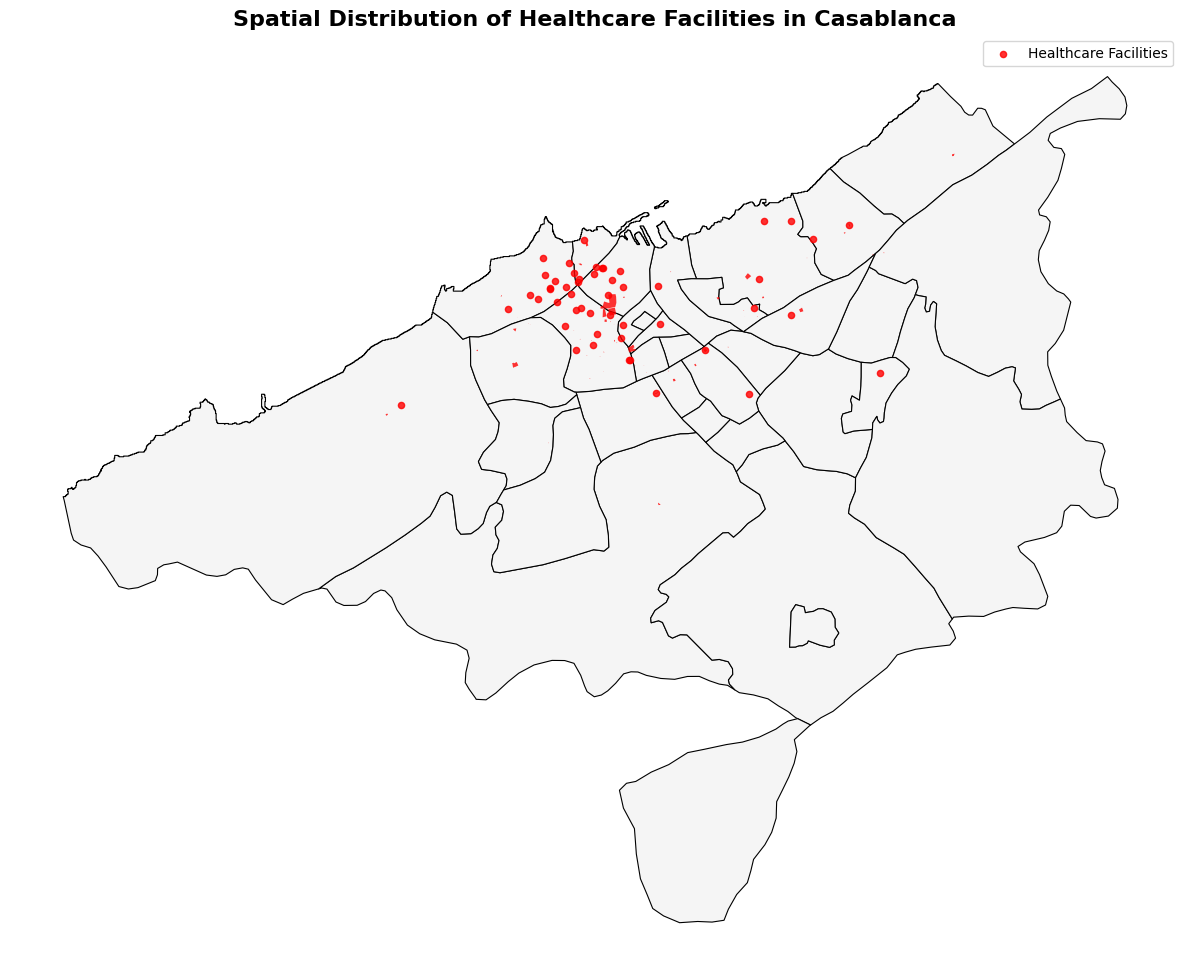

In [15]:
fig, ax = plt.subplots(figsize=(12, 12))

# Plot districts (boundaries)
districts.plot(
    ax=ax,
    edgecolor='black',
    facecolor='#f5f5f5',  # light gray
    linewidth=0.8,
    label='District Boundaries'
)

# Plot healthcare facilities
healthcare.plot(
    ax=ax,
    color='red',
    markersize=20,
    marker='o',
    alpha=0.8,
    label='Healthcare Facilities'
)

# Title
ax.set_title(
    "Spatial Distribution of Healthcare Facilities in Casablanca",
    fontsize=16,
    fontweight='bold'
)

# Remove axis (clean map look)
ax.set_axis_off()

# Add legend
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig(f'{COLLECTION_OUTPUT_DIR}/HealthcareFacilitiesMap.png', bbox_inches='tight')
plt.show()

In [16]:
# Calculate centroids of healthcare facilities and convert to WGS84 for lat/lon
healthcare_proj = healthcare.to_crs(epsg=32629)
centroids = healthcare_proj.geometry.centroid
centroids_wgs84 = centroids.to_crs(epsg=4326)
healthcare['lat'] = centroids_wgs84.y
healthcare['lon'] = centroids_wgs84.x

In [17]:
# Save the healthcare facilities with lat/lon to a new CSV file
healthcare.to_csv(f"{DATA_DIR}/casablanca_healthcare.csv", index=False)

# Population Data (HCP, 2024)

In [19]:
# Load population data from Excel file: Data downloaded from the High Commission for Planning (HCP) of Morocco: Census 2024
population = pd.read_excel(f"{DATA_DIR}/Population légale du Royaume du Maroc selon les résultats du RGPH 2024, format EXCEL.xlsx", header=6)
population.head()

c:\Users\afafb\AppData\Local\Programs\Python\Python310\lib\site-packages\openpyxl\reader\workbook.py:118: UserWarning: Print area cannot be set to Defined name: Population_légale!$A:$G.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")


,Unnamed: 0,Marocains,Étrangers,Population,Ménages,Unnamed: 5,Code géographique
0,Ensemble du territoire national,36680178.0,148152.0,36828330.0,9275038.0,مجموع التراب الوطني,NaN
1,Région de Tanger-Tétouan-Al Hoceima,4020545.0,9677.0,4030222.0,1048860.0,جهة طنجة-تطوان-الحسيمة,1.0
2,Région de l'Oriental,2291040.0,3625.0,2294665.0,575015.0,جهة الشرق,2.0
3,Région de Fès-Meknès,4461182.0,6729.0,4467911.0,1135717.0,جهة فاس-مكناس,3.0
4,Région de Rabat-Salé-Kénitra,5103406.0,29233.0,5132639.0,1301492.0,جهة الرباط-سلا-القنيطرة,4.0


In [ ]:
# Rename columns for clarity
population.columns = [
    "territory_fr",
    "moroccans",
    "foreigners",
    "population",
    "households",
    "territory_ar",
    "geo_code"
]

**Geographic Code Structure**

The dataset uses a hierarchical **geographic code (`geo_code`)** to represent administrative levels in Morocco.

| Level | Meaning | Example |
|------|--------|--------|
| `06` | Region (Casablanca–Settat) | `06` |
| `06.141` | Prefecture of Casablanca | `06.141` |
| `06.141.01` | Commune of Casablanca | `06.141.01` |
| `06.141.01.xx` | Arrondissements (districts) | `06.141.01.01` |

Because of this hierarchy, all districts of Casablanca have geographic codes that **start with `06.141`**.  
This makes it possible to easily filter the dataset to keep only Casablanca administrative units before selecting the arrondissement level for the analysis.

**Selecting specific communes**

In addition to Casablanca arrondissements, some surrounding communes were also selected:
Nouaceur, Bouskoura, Dar Bouazza, Tit Mellil, Mediouna, and Lahraouyine.

These territories are located in the metropolitan area of Casablanca and are relevant for the accessibility analysis because residents often depend on the transport and healthcare services of the city.

Mediouna 06.355                                    
Nouaceur 06.385

In [ ]:
# Filter to only include rows where geo_code starts with "614101" which corresponds to Casablanca
casablanca = population[population["geo_code"].astype(str).str.startswith("614101")]

In [ ]:
# Further filter to only include rows where territory_fr starts with "Arrondissement" to focus on the relevant administrative units within Casablanca
casablanca = casablanca[casablanca["territory_fr"].str.startswith("Arrondissement")]

In [ ]:
# Filter to only include rows where geo_code starts with "635501" which corresponds to Mediouna
mediouna = population[
    population["geo_code"].astype(str).str.startswith("635501")
]

In [ ]:
# Filter to only include rows where geo_code starts with "638501" which corresponds to Nouaceur
nouaceur = population[
    population["geo_code"].astype(str).str.startswith("638501")
]

In [ ]:
# Check unique territory names to understand the structure of the data for each area
mediouna["territory_fr"].unique(), nouaceur["territory_fr"].unique(), casablanca["territory_fr"].unique()

(array(['Commune de Tit Mellil', 'Commune de Mediouna',
        'Commune de Lahraouyine', 'Commune de Sidi Hajjaj Oued Hassar',
        "Commune d'Almajjatia Oulad Taleb"], dtype=object),
 array(['Commune de Nouaceur', 'Commune de Bouskoura',
        'Commune de Dar Bouazza', "Commune d'Oulad Azzouz",
        "Commune d'Ouled Salah", 'dont le centre urbain de Victoria'],
       dtype=object),
 array(["Arrondissement d'Anfa", 'Arrondissement de Maârif',
        'Arrondissement de Sidi Belyout', "Arrondissement d'Al-Fida",
        'Arrondissement de Mers-Sultan', 'Arrondissement de Hay-Mohammadi',
        "Arrondissement d'Asoukhour Assawda", "Arrondissement d'Aïn-Sebaâ",
        'Arrondissement de Hay-Hassani', "Arrondissement d'Aïn-Chock",
        'Arrondissement de Sidi Bernoussi',
        'Arrondissement de Sidi Moumen', "Arrondissement de Ben-M'sick",
        'Arrondissement de Sbata', 'Arrondissement de Moulay Rachid',
        'Arrondissement de Sidi Othmane'], dtype=object))

In [ ]:
# Combine the filtered data for Mediouna, Nouaceur, and Casablanca into a single DataFrame for further analysis
final_population = pd.concat([mediouna, nouaceur, casablanca]).reset_index(drop=True)

In [ ]:
final_population.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   territory_fr  27 non-null     object 
 1   moroccans     27 non-null     float64
 2   foreigners    27 non-null     float64
 3   population    27 non-null     float64
 4   households    27 non-null     float64
 5   territory_ar  27 non-null     object 
 6   geo_code      27 non-null     float64
dtypes: float64(5), object(2)
memory usage: 1.6+ KB


In [ ]:
# Drop unnecessary columns
drop = ["moroccans", "foreigners", "households", "territory_ar", "geo_code"]
final_population.drop(columns=drop, inplace=True)

In [ ]:
# Save the final population data for Casablanca, Mediouna, and Nouaceur to a new CSV file
final_population.to_csv(f"{DATA_DIR}/raw/population.csv", index=False)